# Chapter 13: General Sample Spaces

Source span: printed pages 283-302; PDF pages approximately 298-316. The source was used for orientation: topic order, terminology, and the chapter's sample-space inventory. The lesson, examples, code, diagrams, artifacts, and checks here are original course material.

## Chapter Goal

This chapter asks what changes when directional observations no longer live only on circles and spheres. A cometary orbit, a camera attitude, a crystal orientation, or a fitted local plane may be recorded as a rotation, an orthonormal frame, a subspace, a point on a hyperboloid, or a point on some other manifold. The statistic is only meaningful after the sample space and its invariances have been named.

The computational goal is therefore concrete: represent each observation by an object whose constraints can be checked, choose a model whose canonical statistic respects the observation type, and keep a final audit trail of the relevant manifold identities.

## Computational Translation Guide

| Book concept | Computational object | Constraint to check | Invariance or model route |
|---|---:|---:|---|
| Rotation in three-space | `3 x 3` matrix `R` | `R.T @ R = I`, `det(R) = 1` | left/right action by rotation groups; matrix Fisher score `tr(F.T @ R)` |
| Orthonormal `r`-frame in `R^p` | `p x r` matrix `X` | `X.T @ X = I_r` | Stiefel manifold `V_r(R^p)`; polar part of a full-rank matrix estimates orientation |
| `r`-dimensional subspace | projection matrix `P = X @ X.T` | `P.T = P`, `P @ P = P`, `tr(P) = r` | Grassmann manifold; basis changes `X -> XQ` should not change `P`; matrix Bingham score `tr(A @ P)` |
| Hyperboloid point | vector `x = (x0, x1, x2)` | `x0**2 - x1**2 - x2**2 = 1`, `x0 > 0` | pseudo-orthogonal invariance; no finite uniform probability on the full hyperboloid |
| General manifold sample space | point plus chart, embedding, metric, or group action | membership, tangent, and invariance tests | use geodesic, exponential-map, or quotient-aware summaries instead of flat averages |

The routing rule is simple but strict: if changing coordinates, rotating the ambient frame, or re-basing a subspace changes the scientific answer, the calculation is not yet a statistic on the intended sample space.

In [1]:
from pathlib import Path
import sys


def find_book_root(start: Path) -> Path:
    '''Find the Directional-Statistics course root from a notebook or repo cwd.'''
    start = start.resolve()
    for candidate in [start, *start.parents]:
        direct = candidate
        nested = candidate / "Directional-Statistics"
        for root in (direct, nested):
            if (
                (root / "AGENTS.md").exists()
                and (root / "scripts" / "validate_dirstats_course.py").exists()
                and (root / "utils").exists()
            ):
                return root
    raise RuntimeError("Could not locate Directional-Statistics course root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-13"
SOURCE_SPAN = {"printed": "283-302", "pdf": "298-316"}

print(f"Course root: {BOOK_ROOT.name}")
print(f"Artifact topic: {TOPIC}")

Course root: Directional-Statistics
Artifact topic: chapter-13


In [2]:
import json
import math
import os

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.linalg import expm, polar
import sympy as sp

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.validation import assert_artifacts

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(13013)

def notebook_relative(path):
    return Path(os.path.relpath(Path(path).resolve(), Path.cwd().resolve())).as_posix()


def display_book_artifact(path, **kwargs):
    return display_artifact(notebook_relative(path), **kwargs)


## Visual Storyboard

The notebook uses three concept-named artifacts.

1. `sample-space-constraint-panels.png` places rotations, Stiefel frames, Grassmann projections, and hyperboloid points next to their defining constraints. Inspect the artifact for what must remain true after numerical work.
2. `fisher-bingham-routing.png` shows why frames route to matrix Fisher style scores while subspaces route through projection matrices and matrix Bingham style scores. Inspect the internal re-basing angle: a frame score changes, while the projection score stays fixed.
3. `rotation-frame-subspace-hyperboloid.html` is an interactive Plotly scene. Rotate it and compare the four spaces: oriented frames, polar Stiefel frames, subspace planes, and the upper sheet of the hyperboloid.

Every visual below has a nearby invariant check. The checks are not decoration; they are the contract that tells us which sample space the numeric array is representing.

In [3]:
def skew(v: np.ndarray) -> np.ndarray:
    '''Skew matrix A(v) for the cross-product action w -> v x w.'''
    v = np.asarray(v, dtype=float)
    return np.array(
        [[0.0, -v[2], v[1]], [v[2], 0.0, -v[0]], [-v[1], v[0], 0.0]],
        dtype=float,
    )


def rotation_from_rotvec(v: np.ndarray) -> np.ndarray:
    '''SO(3) exponential map at the identity.'''
    return expm(skew(np.asarray(v, dtype=float)))


def qr_stiefel_frame(matrix: np.ndarray) -> np.ndarray:
    '''QR projection to the Stiefel manifold with deterministic column signs.'''
    q, r = np.linalg.qr(matrix)
    signs = np.sign(np.diag(r))
    signs[signs == 0] = 1.0
    return q[:, : matrix.shape[1]] * signs[: matrix.shape[1]]


def complete_positive_frame(x: np.ndarray) -> np.ndarray:
    '''Complete a 3 x 2 Stiefel frame to a positive SO(3) frame.'''
    normal = np.cross(x[:, 0], x[:, 1])
    normal = normal / np.linalg.norm(normal)
    r = np.column_stack([x[:, 0], x[:, 1], normal])
    if np.linalg.det(r) < 0:
        r[:, 2] *= -1.0
    return r


def plane_rotation(phi: float) -> np.ndarray:
    c, s = np.cos(phi), np.sin(phi)
    return np.array([[c, -s], [s, c]])


def grassmann_projection(x: np.ndarray) -> np.ndarray:
    return x @ x.T


def minkowski_dot(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    y = np.asarray(y)
    return x[..., 0] * y[..., 0] - np.sum(x[..., 1:] * y[..., 1:], axis=-1)


def hyperboloid_point(radius: np.ndarray, angle: np.ndarray) -> np.ndarray:
    return np.stack(
        [np.cosh(radius), np.sinh(radius) * np.cos(angle), np.sinh(radius) * np.sin(angle)],
        axis=-1,
    )


def add_arrow3d(ax, vector, color, label, length=1.0, linestyle="-"):
    vector = np.asarray(vector, dtype=float) * length
    ax.quiver(0, 0, 0, vector[0], vector[1], vector[2], color=color, linewidth=2.4, linestyle=linestyle)
    ax.text(*(1.08 * vector), label, color=color, fontsize=10)


def set_equal_3d(ax, limit=1.25):
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")


def add_plotly_line(fig, points, *, row, col, color, name, width=6, dash=None, showlegend=True):
    points = np.asarray(points, dtype=float)
    fig.add_trace(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="lines+markers",
            line={"color": color, "width": width, **({"dash": dash} if dash else {})},
            marker={"size": 3, "color": color},
            name=name,
            showlegend=showlegend,
        ),
        row=row,
        col=col,
    )

## Rotations and Frames

A rotation matrix is not just nine numbers. It is an oriented orthonormal frame, so the columns are unit vectors, the columns are mutually orthogonal, and the determinant is positive. The exponential map from a skew-symmetric matrix gives a local coordinate system: a small vector in the Lie algebra is turned into a finite rotation by `expm(A(v))`.

A Stiefel point keeps only the first `r` columns of such a frame. For `V_2(R^3)`, the two visible columns are an orthonormal 2-frame; the missing third column is recoverable by the cross product if we need an oriented `SO(3)` frame.

In [4]:
# A reference rotation and a nearby sample of rotations.
R_mode = rotation_from_rotvec(np.array([0.42, -0.28, 0.65]))
rotation_noise = rng.normal(scale=0.18, size=(24, 3))
rotation_sample = np.array([R_mode @ rotation_from_rotvec(v) for v in rotation_noise])
R_bar = rotation_sample.mean(axis=0)
R_bar_polar, _ = polar(R_bar)
if np.linalg.det(R_bar_polar) < 0:
    R_bar_polar[:, -1] *= -1.0

# A Stiefel 2-frame and a full-rank matrix whose polar part is a frame.
raw_frame = np.array([[1.10, -0.35], [0.50, 0.95], [-0.20, 0.55]]) + 0.08 * rng.normal(size=(3, 2))
X_frame = qr_stiefel_frame(raw_frame)
R_from_frame = complete_positive_frame(X_frame)

F_stiefel = X_frame @ np.array([[4.5, 0.65], [0.65, 1.6]]) + 0.18 * rng.normal(size=(3, 2))
polar_frame, polar_concentration = polar(F_stiefel, side="right")

rotation_rayleigh_like = 3 * len(rotation_sample) * np.trace(R_bar.T @ R_bar)

rotation_frame_summary = {
    "rotation_det": float(np.linalg.det(R_mode)),
    "rotation_orthogonality_error": float(np.linalg.norm(R_mode.T @ R_mode - np.eye(3))),
    "polar_mean_det": float(np.linalg.det(R_bar_polar)),
    "stiefel_xtx_error": float(np.linalg.norm(X_frame.T @ X_frame - np.eye(2))),
    "polar_frame_xtx_error": float(np.linalg.norm(polar_frame.T @ polar_frame - np.eye(2))),
    "polar_reconstruction_error": float(np.linalg.norm(polar_frame @ polar_concentration - F_stiefel)),
    "rotation_rayleigh_like": float(rotation_rayleigh_like),
}
rotation_frame_summary

{'rotation_det': 1.0,
 'rotation_orthogonality_error': 2.333832002282171e-16,
 'polar_mean_det': 0.9999999999999992,
 'stiefel_xtx_error': 5.02861556435439e-16,
 'polar_frame_xtx_error': 4.527286508705513e-16,
 'polar_reconstruction_error': 1.3083449600817727e-15,
 'rotation_rayleigh_like': 200.9958286266035}

## Grassmann Projections and Model Routing

A subspace is not the same data type as a chosen frame for that subspace. If `X` and `XQ` differ only by an internal orthogonal re-basing, they describe the same point of the Grassmann manifold. The projection matrix `P = X X.T` removes the basis choice.

This is the practical distinction between matrix Fisher and matrix Bingham routing. If the observation is a rotation or a frame, a matrix Fisher style score can use `X` itself. If the observation is a subspace or an axis, the score must pass through a projection matrix, as in a matrix Bingham style statistic. The next cell makes that distinction measurable.

In [5]:
P_grassmann = grassmann_projection(X_frame)
P_complement = np.eye(3) - P_grassmann

# A trace-zero symmetric parameter for a projection-matrix score.
A_bingham = np.diag([1.7, -0.3, -1.4])
A_bingham = A_bingham - np.trace(A_bingham) * np.eye(3) / 3.0

phis = np.linspace(0.0, 2.0 * np.pi, 241)
fisher_rebase_scores = []
bingham_rebase_scores = []
for phi in phis:
    xq = X_frame @ plane_rotation(phi)
    pq = grassmann_projection(xq)
    fisher_rebase_scores.append(float(np.trace(F_stiefel.T @ xq)))
    bingham_rebase_scores.append(float(np.trace(A_bingham @ pq)))
fisher_rebase_scores = np.array(fisher_rebase_scores)
bingham_rebase_scores = np.array(bingham_rebase_scores)

# A small sample of subspaces, obtained as planes from the first two columns of nearby rotations.
subspace_sample = np.array([r[:, :2] @ r[:, :2].T for r in rotation_sample])
P_bar = subspace_sample.mean(axis=0)
p, r = 3, 2
grassmann_bingham_like = (
    len(subspace_sample) * p * (p + 2) / (2 * r * (p - r))
    * np.trace((P_bar - (r / p) * np.eye(p)) @ (P_bar - (r / p) * np.eye(p)))
)

grassmann_summary = {
    "projection_symmetry_error": float(np.linalg.norm(P_grassmann - P_grassmann.T)),
    "projection_idempotence_error": float(np.linalg.norm(P_grassmann @ P_grassmann - P_grassmann)),
    "projection_trace": float(np.trace(P_grassmann)),
    "complement_projection_error": float(np.linalg.norm(P_complement @ P_complement - P_complement)),
    "basis_invariance_error": float(np.max(np.abs(bingham_rebase_scores - bingham_rebase_scores[0]))),
    "fisher_rebase_score_range": float(np.ptp(fisher_rebase_scores)),
    "grassmann_bingham_like": float(grassmann_bingham_like),
}
grassmann_summary

{'projection_symmetry_error': 0.0,
 'projection_idempotence_error': 5.630346959523356e-16,
 'projection_trace': 2.000000000000001,
 'complement_projection_error': 5.486554932812803e-16,
 'basis_invariance_error': 4.440892098500626e-16,
 'fisher_rebase_score_range': 11.955176605284699,
 'grassmann_bingham_like': 48.55705766832046}

## Hyperboloids and General Manifold Habits

The hyperboloid example changes the metric signature. Points on the upper sheet of `H^2` satisfy `x0^2 - x1^2 - x2^2 = 1`, not the Euclidean unit-sphere identity. The group preserving that bilinear form is a pseudo-orthogonal group, and the full space has infinite invariant volume. That is why this sample space has no finite uniform probability distribution analogous to the sphere.

The general lesson extends beyond this one surface: before averaging, testing, or fitting a model on a manifold, record the constraint, the group action or quotient, and the tangent or exponential-map approximation being used.

In [6]:
# Upper-sheet hyperboloid sample, with one concentrated cluster and a few wider points.
hyper_angles = np.linspace(-0.85, 0.85, 21) + 0.35
hyper_radii = 0.55 + 0.18 * np.cos(np.linspace(0.0, 2.0 * np.pi, 21))
hyper_points = hyperboloid_point(hyper_radii, hyper_angles)
mode_h = hyperboloid_point(np.array(0.62), np.array(0.42))
kappa_h = 2.4
hyper_log_density = -kappa_h * minkowski_dot(mode_h, hyper_points)

hyper_mean_raw = hyper_points.mean(axis=0)
hyper_mean_norm = float(np.sqrt(minkowski_dot(hyper_mean_raw, hyper_mean_raw)))
hyper_mean = hyper_mean_raw / hyper_mean_norm

hyperboloid_summary = {
    "max_minkowski_constraint_error": float(np.max(np.abs(minkowski_dot(hyper_points, hyper_points) - 1.0))),
    "mode_minkowski_constraint_error": float(abs(minkowski_dot(mode_h, mode_h) - 1.0)),
    "mean_resultant_length": hyper_mean_norm,
    "mean_on_hyperboloid_error": float(abs(minkowski_dot(hyper_mean, hyper_mean) - 1.0)),
    "log_density_max_at_near_mode_index": int(np.argmax(hyper_log_density)),
}
hyperboloid_summary

{'max_minkowski_constraint_error': 3.3306690738754696e-16,
 'mode_minkowski_constraint_error': 4.440892098500626e-16,
 'mean_resultant_length': 1.05706333754916,
 'mean_on_hyperboloid_error': 4.440892098500626e-16,
 'log_density_max_at_near_mode_index': 14}

## Artifact 1: Constraint Panels

Representation choice: a static multi-panel figure is durable in rendered notebooks and exports. It places each sample space beside the invariant that defines it.

Inspection target: the rotation panel should look like a complete oriented triad; the Stiefel panel should show only two constrained columns; the Grassmann panel should be read as a matrix object rather than a drawn plane alone; the hyperboloid panel should curve upward while keeping the Minkowski constraint checked in JSON.

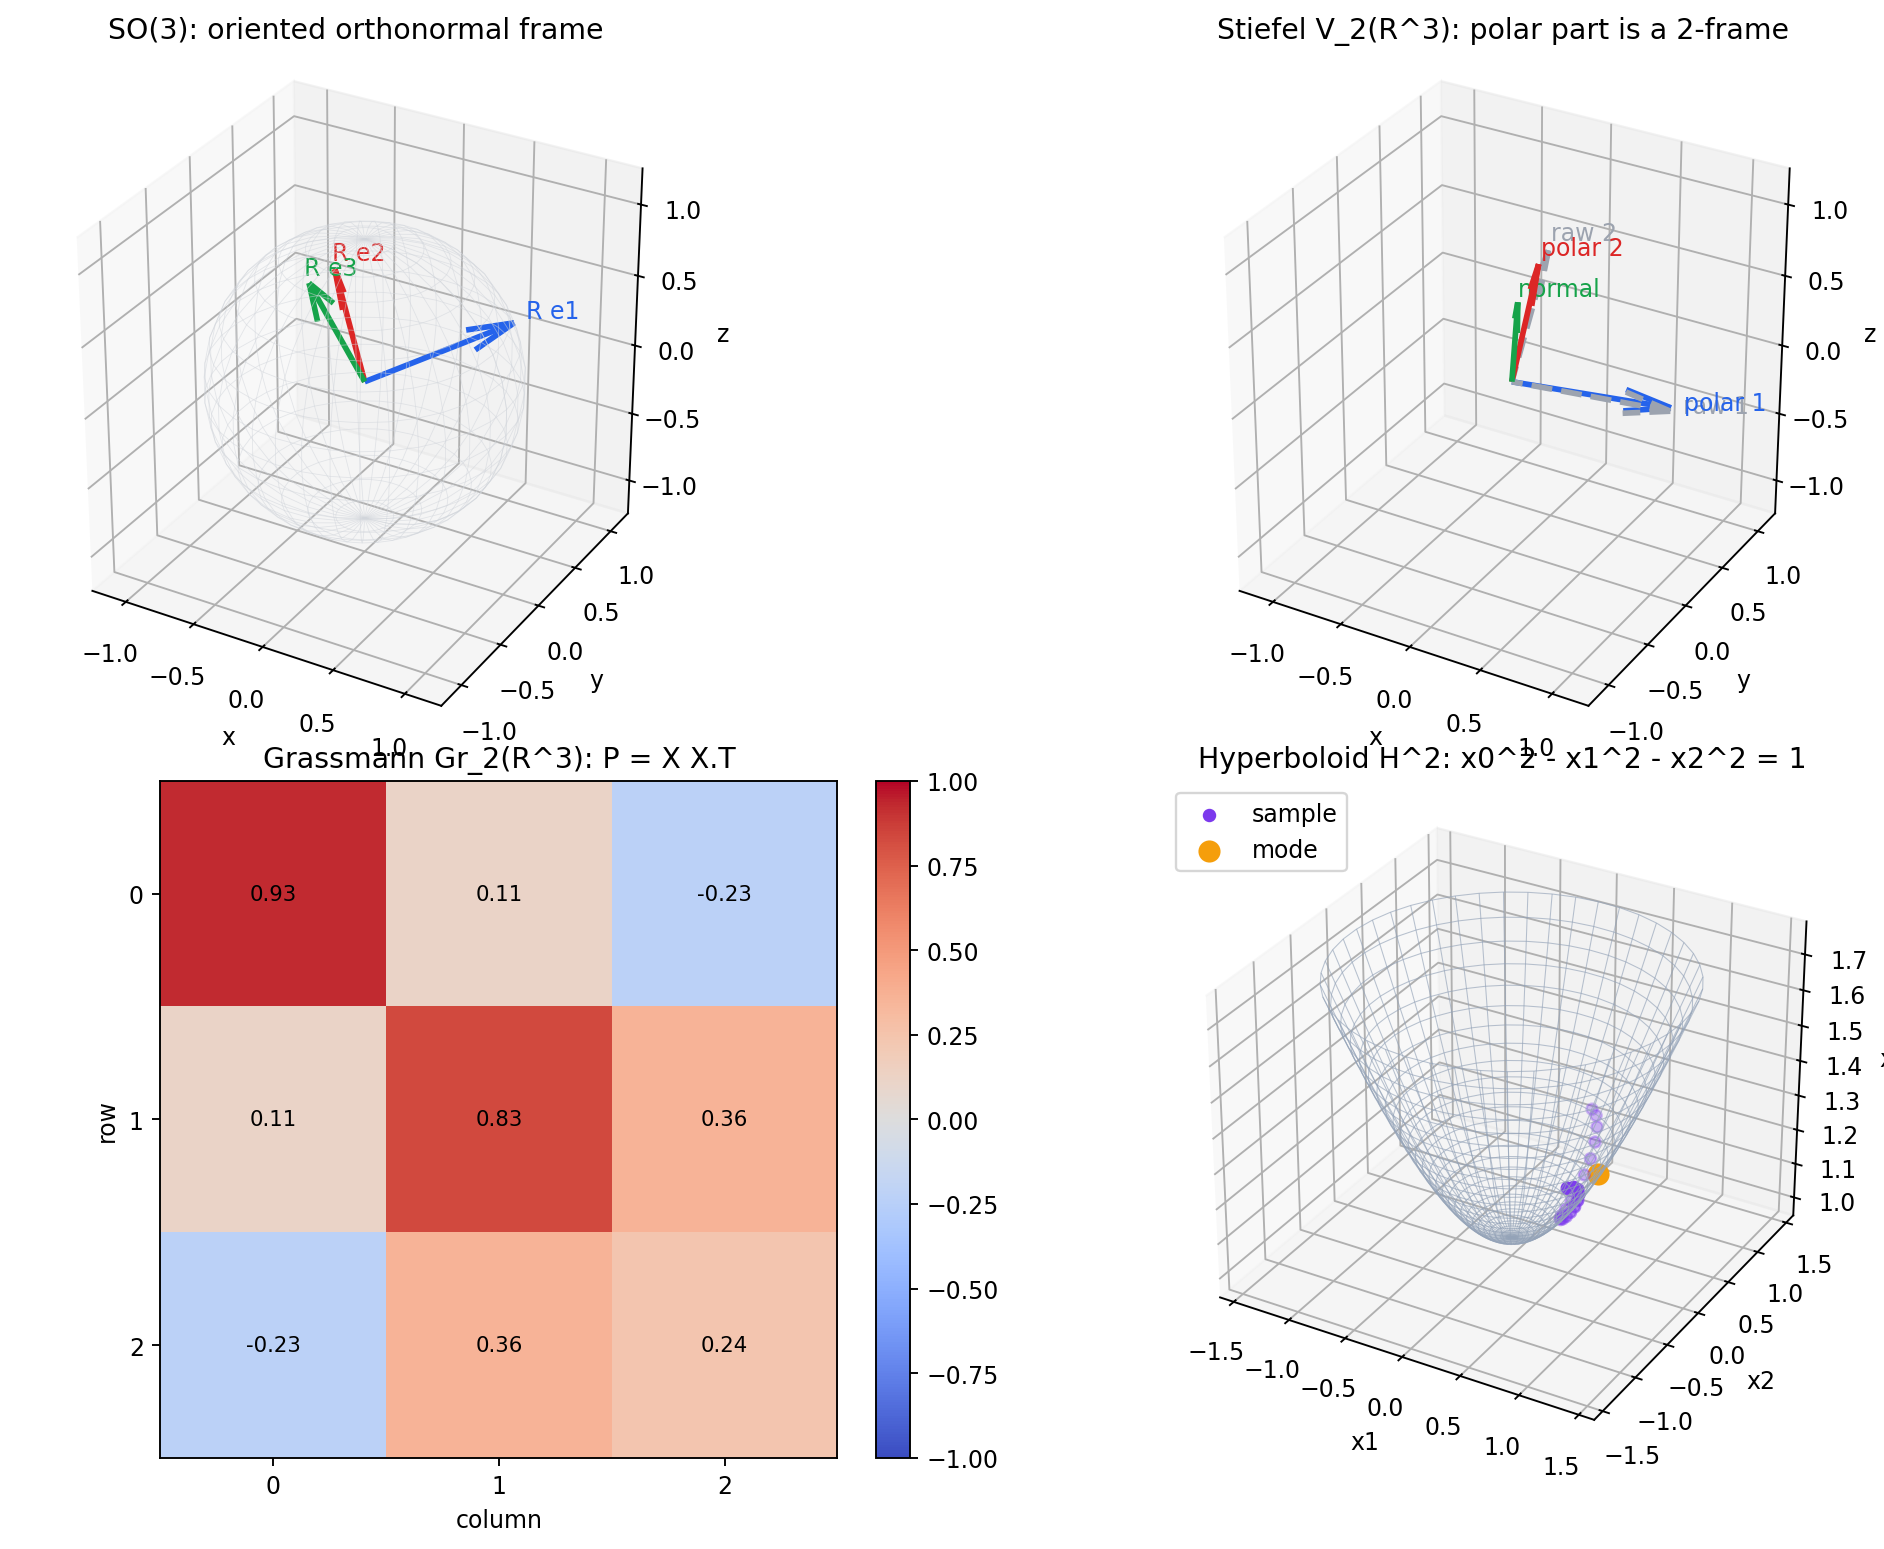

In [7]:
def build_constraint_panels():
    fig = plt.figure(figsize=(12.5, 9.0), constrained_layout=True)
    colors = ["#2563eb", "#dc2626", "#16a34a"]

    # SO(3): complete oriented frame.
    ax1 = fig.add_subplot(2, 2, 1, projection="3d")
    u = np.linspace(0, 2 * np.pi, 36)
    v = np.linspace(0, np.pi, 18)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax1.plot_wireframe(xs, ys, zs, color="#d1d5db", linewidth=0.35, alpha=0.55)
    for j, label in enumerate(["R e1", "R e2", "R e3"]):
        add_arrow3d(ax1, R_mode[:, j], colors[j], label)
    ax1.set_title("SO(3): oriented orthonormal frame")
    set_equal_3d(ax1, 1.25)

    # Stiefel: two columns plus polar orientation.
    ax2 = fig.add_subplot(2, 2, 2, projection="3d")
    for j, color in enumerate(colors[:2]):
        add_arrow3d(ax2, raw_frame[:, j] / max(np.linalg.norm(raw_frame[:, j]), 1e-12), "#9ca3af", f"raw {j+1}", linestyle="--")
        add_arrow3d(ax2, polar_frame[:, j], color, f"polar {j+1}")
    add_arrow3d(ax2, np.cross(polar_frame[:, 0], polar_frame[:, 1]), "#16a34a", "normal", length=0.75)
    ax2.set_title("Stiefel V_2(R^3): polar part is a 2-frame")
    set_equal_3d(ax2, 1.25)

    # Grassmann: projection matrix as the coordinate-free subspace record.
    ax3 = fig.add_subplot(2, 2, 3)
    im = ax3.imshow(P_grassmann, vmin=-1, vmax=1, cmap="coolwarm")
    for i in range(3):
        for j in range(3):
            ax3.text(j, i, f"{P_grassmann[i, j]:.2f}", ha="center", va="center", fontsize=9)
    ax3.set_xticks([0, 1, 2])
    ax3.set_yticks([0, 1, 2])
    ax3.set_title("Grassmann Gr_2(R^3): P = X X.T")
    ax3.set_xlabel("column")
    ax3.set_ylabel("row")
    fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

    # Hyperboloid: upper sheet embedded in R^3 with the Minkowski metric.
    ax4 = fig.add_subplot(2, 2, 4, projection="3d")
    rr = np.linspace(0.0, 1.15, 28)
    tt = np.linspace(0.0, 2.0 * np.pi, 48)
    RR, TT = np.meshgrid(rr, tt)
    H = hyperboloid_point(RR, TT)
    ax4.plot_wireframe(H[..., 1], H[..., 2], H[..., 0], color="#94a3b8", linewidth=0.45, alpha=0.65)
    ax4.scatter(hyper_points[:, 1], hyper_points[:, 2], hyper_points[:, 0], color="#7c3aed", s=22, label="sample")
    ax4.scatter([mode_h[1]], [mode_h[2]], [mode_h[0]], color="#f59e0b", s=70, label="mode")
    ax4.set_title("Hyperboloid H^2: x0^2 - x1^2 - x2^2 = 1")
    ax4.set_xlabel("x1")
    ax4.set_ylabel("x2")
    ax4.set_zlabel("x0")
    ax4.set_box_aspect((1, 1, 0.8))
    ax4.legend(loc="upper left")
    return fig


constraint_fig = build_constraint_panels()
constraint_png = save_matplotlib(constraint_fig, TOPIC, "core", "sample-space-constraint-panels.png", dpi=170)
plt.close(constraint_fig)
display_book_artifact(constraint_png, width=900)

## Artifact 2: Matrix Fisher or Matrix Bingham?

Representation choice: a score curve makes the routing decision visible. Re-basing a two-frame inside its own plane is a real change for a frame observation, but it is not a real change for a subspace observation.

Inspection target: the matrix Fisher style score varies with the internal `O(2)` angle because it sees a frame; the matrix Bingham style projection score is flat because it sees only the subspace.

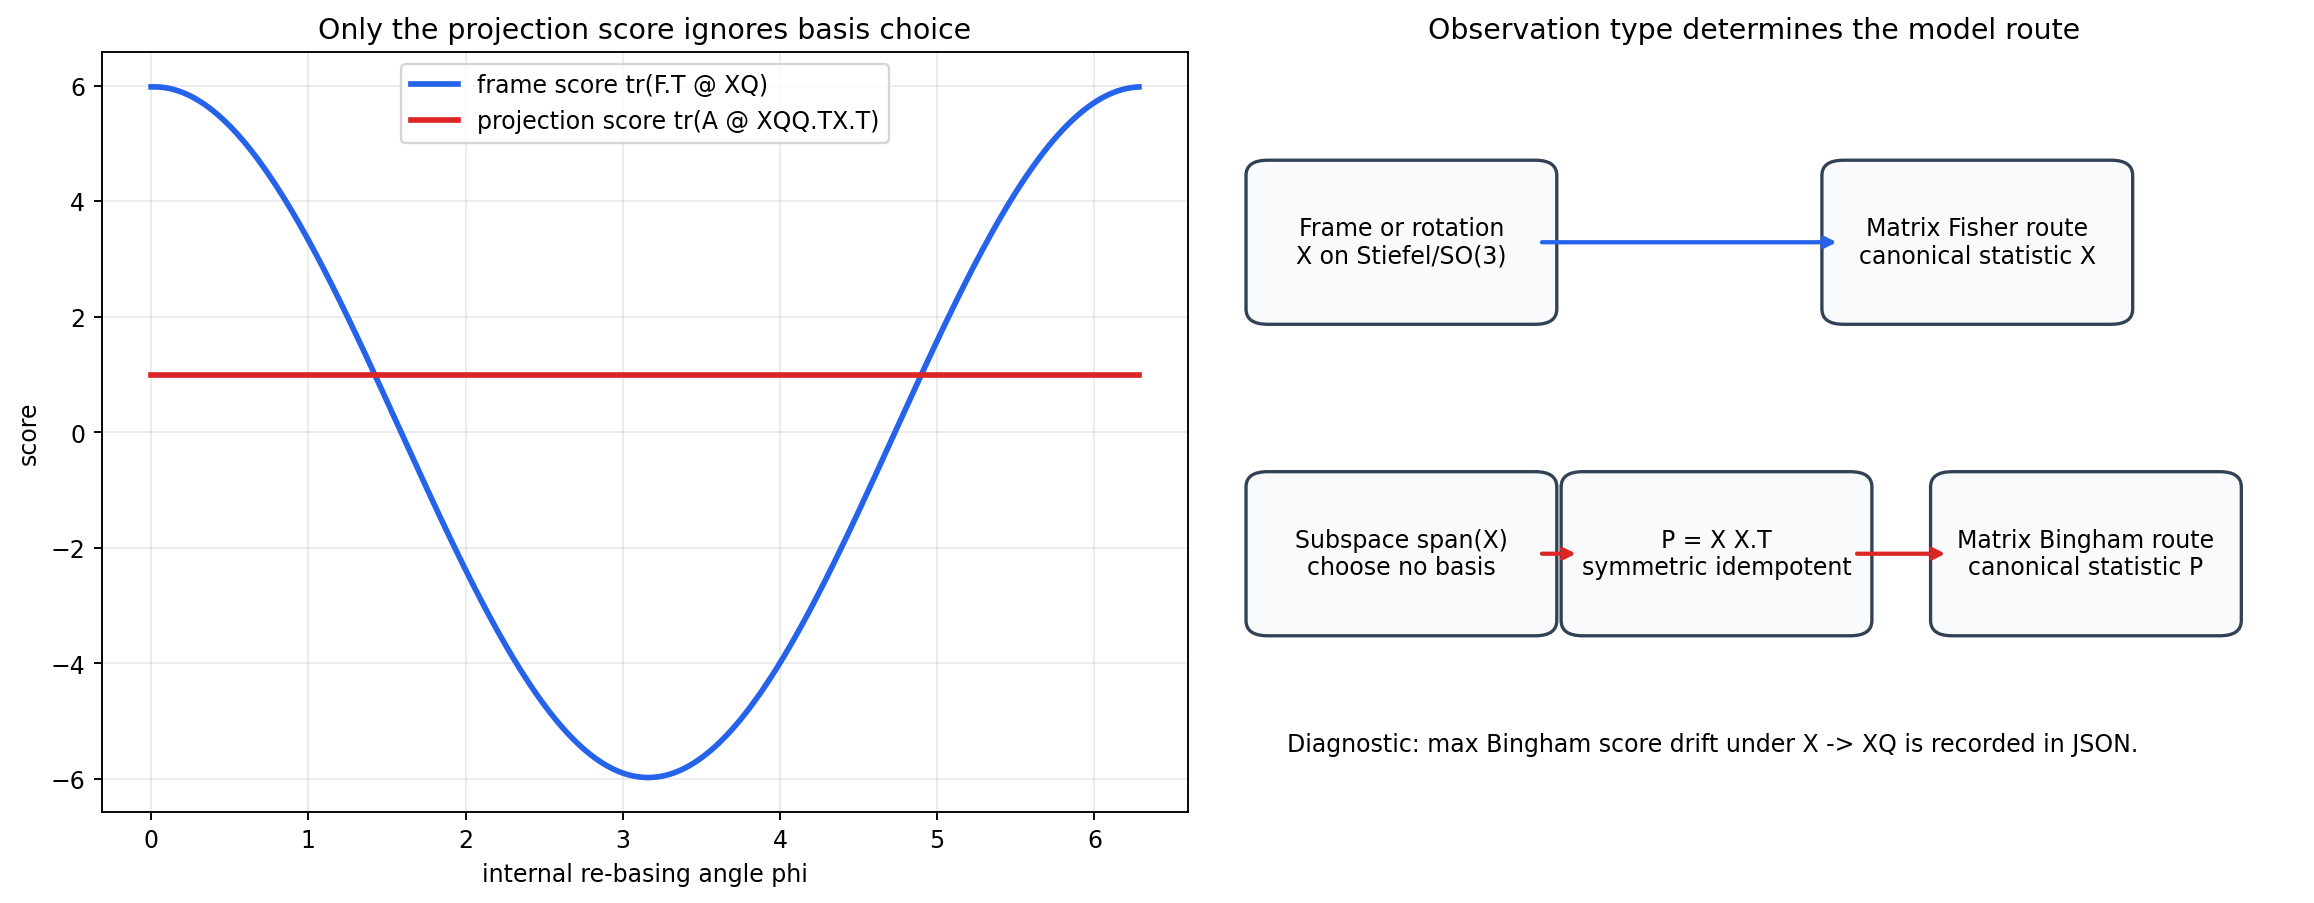

In [8]:
def build_routing_figure():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)

    ax1.plot(phis, fisher_rebase_scores, color="#2563eb", lw=2.4, label="frame score tr(F.T @ XQ)")
    ax1.plot(phis, bingham_rebase_scores, color="#dc2626", lw=2.4, label="projection score tr(A @ XQQ.TX.T)")
    ax1.set_xlabel("internal re-basing angle phi")
    ax1.set_ylabel("score")
    ax1.set_title("Only the projection score ignores basis choice")
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="best")

    ax2.set_axis_off()
    ax2.set_title("Observation type determines the model route")
    boxes = {
        "frame": (0.05, 0.66, "Frame or rotation\nX on Stiefel/SO(3)"),
        "fisher": (0.58, 0.66, "Matrix Fisher route\ncanonical statistic X"),
        "subspace": (0.05, 0.25, "Subspace span(X)\nchoose no basis"),
        "proj": (0.34, 0.25, "P = X X.T\nsymmetric idempotent"),
        "bingham": (0.68, 0.25, "Matrix Bingham route\ncanonical statistic P"),
    }
    for key, (x, y, text) in boxes.items():
        patch = FancyBboxPatch(
            (x, y),
            0.25,
            0.18,
            boxstyle="round,pad=0.018,rounding_size=0.02",
            ec="#334155",
            fc="#f8fafc",
            lw=1.4,
            transform=ax2.transAxes,
        )
        ax2.add_patch(patch)
        ax2.text(x + 0.125, y + 0.09, text, ha="center", va="center", fontsize=10, transform=ax2.transAxes)

    def arrow(start, end, color="#334155"):
        ax2.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops={"arrowstyle": "->", "lw": 1.8, "color": color},
            xycoords=ax2.transAxes,
        )

    arrow((0.30, 0.75), (0.58, 0.75), "#2563eb")
    arrow((0.30, 0.34), (0.34, 0.34), "#dc2626")
    arrow((0.59, 0.34), (0.68, 0.34), "#dc2626")
    ax2.text(0.07, 0.08, "Diagnostic: max Bingham score drift under X -> XQ is recorded in JSON.", fontsize=10, transform=ax2.transAxes)
    return fig


routing_fig = build_routing_figure()
routing_png = save_matplotlib(routing_fig, TOPIC, "core", "fisher-bingham-routing.png", dpi=170)
plt.close(routing_fig)
display_book_artifact(routing_png, width=920)

## Artifact 3: Interactive Manifold Scene

Representation choice: Plotly makes the 3D constraints inspectable without relying on a textbook figure or a static camera angle. The same scene also separates four object types that are easy to confuse when they are all stored as arrays.

Inspection target: rotate each panel. In the Grassmann panel, move your eye from the chosen basis vectors to the plane they span; the plane, not the arrows, is the observation. In the hyperboloid panel, the vertical coordinate is `x0`, so points remain on the upper sheet rather than on a sphere.

In [9]:
def sphere_surface(radius=1.0, n=32):
    u = np.linspace(0, 2 * np.pi, n)
    v = np.linspace(0, np.pi, n // 2)
    uu, vv = np.meshgrid(u, v)
    return radius * np.cos(uu) * np.sin(vv), radius * np.sin(uu) * np.sin(vv), radius * np.cos(vv)


def build_interactive_scene():
    fig = make_subplots(
        rows=2,
        cols=2,
        specs=[[{"type": "scene"}, {"type": "scene"}], [{"type": "scene"}, {"type": "scene"}]],
        subplot_titles=("SO(3) rotation", "Stiefel polar frame", "Grassmann projection", "Hyperboloid H^2"),
        horizontal_spacing=0.02,
        vertical_spacing=0.04,
    )

    sx, sy, sz = sphere_surface()
    fig.add_trace(
        go.Surface(x=sx, y=sy, z=sz, opacity=0.16, colorscale=[[0, "#dbeafe"], [1, "#dbeafe"]], showscale=False, name="unit sphere"),
        row=1,
        col=1,
    )
    for j, color in enumerate(["#2563eb", "#dc2626", "#16a34a"]):
        add_plotly_line(fig, np.vstack([np.zeros(3), R_mode[:, j]]), row=1, col=1, color=color, name=f"R e{j+1}")

    for j, color in enumerate(["#2563eb", "#dc2626"]):
        add_plotly_line(fig, np.vstack([np.zeros(3), raw_frame[:, j] / np.linalg.norm(raw_frame[:, j])]), row=1, col=2, color="#9ca3af", name=f"raw {j+1}", width=3, dash="dash")
        add_plotly_line(fig, np.vstack([np.zeros(3), polar_frame[:, j]]), row=1, col=2, color=color, name=f"polar {j+1}")
    add_plotly_line(fig, np.vstack([np.zeros(3), np.cross(polar_frame[:, 0], polar_frame[:, 1])]), row=1, col=2, color="#16a34a", name="polar normal")

    grid = np.linspace(-1.05, 1.05, 18)
    U, V = np.meshgrid(grid, grid)
    plane = U[..., None] * X_frame[:, 0] + V[..., None] * X_frame[:, 1]
    fig.add_trace(
        go.Surface(x=plane[..., 0], y=plane[..., 1], z=plane[..., 2], opacity=0.34, colorscale=[[0, "#bfdbfe"], [1, "#bfdbfe"]], showscale=False, name="span(X)"),
        row=2,
        col=1,
    )
    test_vectors = np.array([[0.95, 0.45, 0.7], [-0.7, 0.8, 0.35], [0.45, -0.95, 0.85]])
    for k, vec in enumerate(test_vectors):
        proj = P_grassmann @ vec
        add_plotly_line(fig, np.vstack([np.zeros(3), vec]), row=2, col=1, color="#64748b", name=f"ambient v{k+1}", width=3, dash="dash", showlegend=(k == 0))
        add_plotly_line(fig, np.vstack([np.zeros(3), proj]), row=2, col=1, color="#dc2626", name=f"P v{k+1}", width=5, showlegend=(k == 0))

    xy = np.linspace(-1.45, 1.45, 42)
    X1, X2 = np.meshgrid(xy, xy)
    X0 = np.sqrt(1.0 + X1**2 + X2**2)
    fig.add_trace(
        go.Surface(x=X1, y=X2, z=X0, opacity=0.48, colorscale="Viridis", showscale=False, name="H^2"),
        row=2,
        col=2,
    )
    fig.add_trace(
        go.Scatter3d(
            x=hyper_points[:, 1],
            y=hyper_points[:, 2],
            z=hyper_points[:, 0],
            mode="markers",
            marker={"size": 4, "color": hyper_log_density, "colorscale": "Plasma"},
            name="hyperboloid sample",
        ),
        row=2,
        col=2,
    )
    fig.add_trace(
        go.Scatter3d(x=[mode_h[1]], y=[mode_h[2]], z=[mode_h[0]], mode="markers", marker={"size": 7, "color": "#f59e0b"}, name="hyperboloid mode"),
        row=2,
        col=2,
    )

    scene_template = {
        "xaxis": {"range": [-1.6, 1.6], "backgroundcolor": "white", "gridcolor": "#e5e7eb"},
        "yaxis": {"range": [-1.6, 1.6], "backgroundcolor": "white", "gridcolor": "#e5e7eb"},
        "zaxis": {"range": [-1.6, 1.8], "backgroundcolor": "white", "gridcolor": "#e5e7eb"},
        "aspectmode": "cube",
    }
    fig.update_layout(
        height=820,
        width=1120,
        title="Chapter 13 manifold objects: rotate the panels and inspect the constraints",
        legend={"orientation": "h", "y": -0.04},
        margin={"l": 0, "r": 0, "t": 70, "b": 20},
    )
    for key in ["scene", "scene2", "scene3", "scene4"]:
        fig.update_layout({key: scene_template})
    return fig


interactive_fig = build_interactive_scene()
interactive_html = save_plotly_html(
    interactive_fig,
    TOPIC,
    "interactive",
    "rotation-frame-subspace-hyperboloid.html",
    include_plotlyjs=True,
)
display_book_artifact(interactive_html, width="100%", height=720)

## Proof and Invariant Scaffold

The matrix exponential for rotations depends on the special algebra of skew-symmetric matrices. The exact identity below, `A(v)^3 = -||v||^2 A(v)`, is the algebraic reason Rodrigues' finite formula exists for `SO(3)`. The numerical checks then apply the same principle at the sample-space level: test the identity that defines the space, and test the invariance that defines the statistic.

In [10]:
a, b, c = sp.symbols("a b c")
K = sp.Matrix([[0, -c, b], [c, 0, -a], [-b, a, 0]])
norm2 = a**2 + b**2 + c**2
skew_cubic_residual = sp.simplify(K**3 + norm2 * K)
skew_cubic_identity = all(sp.simplify(entry) == 0 for entry in skew_cubic_residual)
assert skew_cubic_identity

# Numerical identities that define the sample spaces and the routing decision.
invariant_checks = {
    "source_span": SOURCE_SPAN,
    "so3": {
        "orthogonality_error": rotation_frame_summary["rotation_orthogonality_error"],
        "determinant": rotation_frame_summary["rotation_det"],
        "polar_mean_determinant": rotation_frame_summary["polar_mean_det"],
        "rayleigh_like_statistic": rotation_frame_summary["rotation_rayleigh_like"],
    },
    "stiefel": {
        "frame_xtx_error": rotation_frame_summary["stiefel_xtx_error"],
        "polar_frame_xtx_error": rotation_frame_summary["polar_frame_xtx_error"],
        "polar_reconstruction_error": rotation_frame_summary["polar_reconstruction_error"],
        "polar_concentration_eigenvalues": [float(x) for x in np.linalg.eigvalsh(polar_concentration)],
    },
    "grassmann": grassmann_summary,
    "hyperboloid": hyperboloid_summary,
    "model_routing": {
        "fisher_rebase_score_range": grassmann_summary["fisher_rebase_score_range"],
        "bingham_rebase_score_drift": grassmann_summary["basis_invariance_error"],
    },
    "symbolic": {"skew_cubic_identity": bool(skew_cubic_identity)},
}

# Assertions are deliberately tight because these are algebraic construction checks, not statistical p-values.
assert invariant_checks["so3"]["orthogonality_error"] < 1e-12
assert abs(invariant_checks["so3"]["determinant"] - 1.0) < 1e-12
assert invariant_checks["stiefel"]["frame_xtx_error"] < 1e-12
assert invariant_checks["stiefel"]["polar_frame_xtx_error"] < 1e-12
assert invariant_checks["grassmann"]["projection_symmetry_error"] < 1e-12
assert invariant_checks["grassmann"]["projection_idempotence_error"] < 1e-12
assert abs(invariant_checks["grassmann"]["projection_trace"] - 2.0) < 1e-12
assert invariant_checks["grassmann"]["basis_invariance_error"] < 1e-12
assert invariant_checks["grassmann"]["fisher_rebase_score_range"] > 1e-3
assert invariant_checks["hyperboloid"]["max_minkowski_constraint_error"] < 1e-12
assert invariant_checks["hyperboloid"]["mode_minkowski_constraint_error"] < 1e-12
assert invariant_checks["hyperboloid"]["mean_on_hyperboloid_error"] < 1e-12
assert invariant_checks["symbolic"]["skew_cubic_identity"]

invariant_path = save_json(invariant_checks, TOPIC, "checks", "manifold-invariants.json")
display_book_artifact(invariant_path)
invariant_checks

{'source_span': {'printed': '283-302', 'pdf': '298-316'},
 'so3': {'orthogonality_error': 2.333832002282171e-16,
  'determinant': 1.0,
  'polar_mean_determinant': 0.9999999999999992,
  'rayleigh_like_statistic': 200.9958286266035},
 'stiefel': {'frame_xtx_error': 5.02861556435439e-16,
  'polar_frame_xtx_error': 4.527286508705513e-16,
  'polar_reconstruction_error': 1.3083449600817727e-15,
  'polar_concentration_eigenvalues': [1.3974643491493464, 4.600058629910513]},
 'grassmann': {'projection_symmetry_error': 0.0,
  'projection_idempotence_error': 5.630346959523356e-16,
  'projection_trace': 2.000000000000001,
  'complement_projection_error': 5.486554932812803e-16,
  'basis_invariance_error': 4.440892098500626e-16,
  'fisher_rebase_score_range': 11.955176605284699,
  'grassmann_bingham_like': 48.55705766832046},
 'hyperboloid': {'max_minkowski_constraint_error': 3.3306690738754696e-16,
  'mode_minkowski_constraint_error': 4.440892098500626e-16,
  'mean_resultant_length': 1.057063337549

## Applied Lab: Classify Before Computing

Use this checklist for a new data set.

1. Name the observation type: vector, axis, rotation, frame, subspace, hyperboloid point, or other manifold point.
2. Write the membership constraint as code before computing summaries.
3. Name the group action that should not change the answer.
4. Route the model through the correct canonical statistic: `X` for frames and rotations, `X X.T` for subspaces, Minkowski products for hyperboloids, and chart/geodesic-aware summaries for general manifolds.
5. Save at least one artifact and one JSON check that a reader can inspect without the source PDF.

The lab summary below is a compact record of those decisions for this chapter's synthetic examples.

In [11]:
lab_summary = {
    "rotation_data": {
        "space": "SO(3)",
        "object_shape": list(R_mode.shape),
        "model_route": "matrix Fisher style score tr(F.T @ R)",
        "core_check": "R.T @ R = I and det(R) = 1",
    },
    "frame_data": {
        "space": "Stiefel V_2(R^3)",
        "object_shape": list(X_frame.shape),
        "model_route": "matrix Fisher on Stiefel frames; polar part estimates orientation",
        "core_check": "X.T @ X = I_2",
    },
    "subspace_data": {
        "space": "Grassmann Gr_2(R^3)",
        "object_shape": list(P_grassmann.shape),
        "model_route": "matrix Bingham style score tr(A @ P)",
        "core_check": "P.T = P, P @ P = P, tr(P) = 2",
    },
    "hyperboloid_data": {
        "space": "upper sheet H^2",
        "object_shape": list(hyper_points.shape),
        "model_route": "density uses Minkowski product p * x, not Euclidean dot product",
        "core_check": "x0^2 - x1^2 - x2^2 = 1 and x0 > 0",
    },
}
lab_summary_path = save_json(lab_summary, TOPIC, "checks", "lab-routing-summary.json")
display_book_artifact(lab_summary_path)
lab_summary

{'rotation_data': {'space': 'SO(3)',
  'object_shape': [3, 3],
  'model_route': 'matrix Fisher style score tr(F.T @ R)',
  'core_check': 'R.T @ R = I and det(R) = 1'},
 'frame_data': {'space': 'Stiefel V_2(R^3)',
  'object_shape': [3, 2],
  'model_route': 'matrix Fisher on Stiefel frames; polar part estimates orientation',
  'core_check': 'X.T @ X = I_2'},
 'subspace_data': {'space': 'Grassmann Gr_2(R^3)',
  'object_shape': [3, 3],
  'model_route': 'matrix Bingham style score tr(A @ P)',
  'core_check': 'P.T = P, P @ P = P, tr(P) = 2'},
 'hyperboloid_data': {'space': 'upper sheet H^2',
  'object_shape': [21, 3],
  'model_route': 'density uses Minkowski product p * x, not Euclidean dot product',
  'core_check': 'x0^2 - x1^2 - x2^2 = 1 and x0 > 0'}}

## Final Sanity Checks

The final cell checks both kinds of contract. File checks make sure the book-local artifacts exist and have nonzero size. Geometry checks make sure the displayed arrays still live on the intended sample spaces.

In [ ]:
# Display each generated artifact near the end so visual audits and static readers see the full chapter trail.
for extra_artifact in [constraint_png, routing_png, interactive_html, invariant_path, lab_summary_path]:
    if str(extra_artifact).endswith(".html"):
        display_artifact(extra_artifact, width="100%", height=560)
    else:
        display_artifact(extra_artifact, width=900)


In [12]:
artifact_paths = [constraint_png, routing_png, interactive_html, invariant_path, lab_summary_path]
artifact_records = assert_artifacts(artifact_paths, min_bytes=100)

final_sanity = {
    "source_span": SOURCE_SPAN,
    "pdf_used_for": "orientation only",
    "standalone_contract": "original prose, generated artifacts, executable manifold checks",
    "artifact_records": artifact_records,
    "checks_passed": {
        "so3_orthogonal": invariant_checks["so3"]["orthogonality_error"] < 1e-12,
        "so3_det_one": abs(invariant_checks["so3"]["determinant"] - 1.0) < 1e-12,
        "stiefel_frame_constraint": invariant_checks["stiefel"]["frame_xtx_error"] < 1e-12,
        "grassmann_symmetric": invariant_checks["grassmann"]["projection_symmetry_error"] < 1e-12,
        "grassmann_idempotent": invariant_checks["grassmann"]["projection_idempotence_error"] < 1e-12,
        "grassmann_basis_invariant": invariant_checks["grassmann"]["basis_invariance_error"] < 1e-12,
        "hyperboloid_constraint": invariant_checks["hyperboloid"]["max_minkowski_constraint_error"] < 1e-12,
        "symbolic_so3_rodrigues_scaffold": invariant_checks["symbolic"]["skew_cubic_identity"],
        "artifact_existence_nonzero_size": all(record["exists"] and record["bytes"] > 100 for record in artifact_records),
    },
    "concept_artifacts": [record["path"] for record in artifact_records],
}

assert all(final_sanity["checks_passed"].values())
final_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
assert_artifacts([final_path], min_bytes=100)
display_book_artifact(final_path)
final_sanity

{'source_span': {'printed': '283-302', 'pdf': '298-316'},
 'pdf_used_for': 'orientation only',
 'standalone_contract': 'original prose, generated artifacts, executable manifold checks',
 'artifact_records': [{'path': 'artifacts/chapter-13/core/sample-space-constraint-panels.png',
   'exists': True,
   'bytes': 560429},
  {'path': 'artifacts/chapter-13/core/fisher-bingham-routing.png',
   'exists': True,
   'bytes': 137583},
  {'path': 'artifacts/chapter-13/interactive/rotation-frame-subspace-hyperboloid.html',
   'exists': True,
   'bytes': 4970950},
  {'path': 'artifacts/chapter-13/checks/manifold-invariants.json',
   'exists': True,
   'bytes': 1435},
  {'path': 'artifacts/chapter-13/checks/lab-routing-summary.json',
   'exists': True,
   'bytes': 929}],
 'checks_passed': {'so3_orthogonal': True,
  'so3_det_one': True,
  'stiefel_frame_constraint': True,
  'grassmann_symmetric': True,
  'grassmann_idempotent': True,
  'grassmann_basis_invariant': True,
  'hyperboloid_constraint': Tru

## Takeaways

General sample spaces turn directional statistics into a geometry-first workflow. Rotations and frames carry orthogonality constraints. Subspaces should be stored as projections when the chosen basis is not part of the observation. Hyperboloid data use an indefinite metric and do not inherit a finite uniform probability distribution from compact directional spaces. General manifold problems need the same habit: state the constraint, state the invariance group or quotient, choose a statistic that respects it, and save checks that make the choice auditable.